In [1]:
import pandas as pd

print("Cargando datos...")
df = pd.read_csv(r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\raw\entrenamiento.csv')
#                                    ↑ La 'r' antes de las comillas evita problemas con \

print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Cargando datos...
✅ Dataset cargado: 992192 filas, 25 columnas


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
0,556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,...,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


Columnas Prioritarias para tu Rol Junior

In [2]:
columnas_core = [
    'operation_type',      # Filtrar solo ventas
    'property_type',       # Segmentar producto
    'l2', 'l4',            # Provincia y barrio
    'surface_total',       # Tamaño
    'rooms', 'bedrooms',   # Configuración
    'currency', 'price',   # Precio (target)
    'start_date', 'end_date'  # Tiempo en mercado
]

In [3]:
print("📊 RESUMEN DE CALIDAD DE DATOS")
print("="*60)

# 1. Tipos de datos
print("\n1️⃣ Tipos de datos:")
print(df[columnas_core].dtypes)

# 2. Valores nulos (% por columna)
print("\n2️⃣ Porcentaje de valores nulos:")
null_pct = df[columnas_core].isnull().mean() * 100
print(null_pct[null_pct > 0].sort_values(ascending=False))

# 3. Valores únicos en categóricas clave
print("\n3️⃣ Valores únicos en columnas clave:")
for col in ['operation_type', 'property_type', 'currency', 'l2']:
    print(f"{col}: {df[col].dropna().nunique()} únicos → {df[col].dropna().unique()[:5]}")

# 4. Rango de precios (para detectar outliers)
print("\n4️⃣ Estadísticas de precio:")
print(df[df['currency']=='USD']['price'].describe())

📊 RESUMEN DE CALIDAD DE DATOS

1️⃣ Tipos de datos:
operation_type        str
property_type         str
l2                    str
l4                    str
surface_total     float64
rooms             float64
bedrooms          float64
currency              str
price             float64
start_date            str
end_date              str
dtype: object

2️⃣ Porcentaje de valores nulos:
l4               77.283127
bedrooms         60.622642
surface_total    54.830920
rooms            49.299632
currency          4.762284
price             4.473025
dtype: float64

3️⃣ Valores únicos en columnas clave:
operation_type: 3 únicos → <StringArray>
['Venta', 'Alquiler', 'Alquiler temporal']
Length: 3, dtype: str
property_type: 10 únicos → <StringArray>
['Departamento', 'PH', 'Cochera', 'Casa', 'Lote']
Length: 5, dtype: str
currency: 4 únicos → <StringArray>
['USD', 'ARS', 'UYU', 'PEN']
Length: 4, dtype: str
l2: 42 únicos → <StringArray>
[         'Capital Federal',   'Bs.As. G.B.A. Zona Sur',
    'Bu

In [4]:
print("Ventas por moneda:")
ventas_por_moneda = df[df['operation_type'] == 'Venta']['currency'].value_counts()
print(ventas_por_moneda)
print(f"\n% en USD: {ventas_por_moneda.get('USD', 0) / ventas_por_moneda.sum() * 100:.1f}%")

Ventas por moneda:
currency
USD    696691
ARS     31663
PEN        25
UYU         4
Name: count, dtype: int64

% en USD: 95.6%


In [5]:
import pandas as pd
import numpy as np

print("🔧 Iniciando limpieza de datos...")

# 1. Filtrar solo VENTAS (nuestro foco)
df = df[df['operation_type'] == 'Venta'].copy()
print(f"✅ Filtrado ventas: {len(df)} filas")

# 2. Convertir fechas
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# 3. Calcular tiempo en mercado (días)
df['days_on_market'] = (df['end_date'] - df['start_date']).dt.days

# 4. Filtrar precios realistas en USD
df = df[
    (df['currency'] == 'USD') &
    (df['price'] >= 10_000) &
    (df['price'] <= 2_000_000) &
    (df['price'].notna())
].copy()
print(f"✅ Filtrado por precio/moneda: {len(df)} filas")

# 5. Crear precio por m² (solo donde hay superficie)
df['price_per_m2'] = df['price'] / df['surface_total']

# 6. Limpiar columnas de ubicación (usar l2 y l3 que tienen menos nulos)
df['provincia'] = df['l2'].str.strip().str.title()
df['ciudad'] = df['l3'].str.strip().str.title()

print(f"✅ Dataset limpio final: {df.shape}")
print(f"   Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

🔧 Iniciando limpieza de datos...
✅ Filtrado ventas: 762318 filas
✅ Filtrado por precio/moneda: 689884 filas
✅ Dataset limpio final: (689884, 29)
   Filas: 689,884 | Columnas: 29


In [6]:
print("📈 RESUMEN POST-LIMPIEZA")
print("="*50)
print(f"Filas finales: {len(df):,}")
print(f"\nDistribución por provincia (top 5):")
print(df['provincia'].value_counts().head())
print(f"\nPrecio promedio por m² (USD): ${df['price_per_m2'].mean():,.0f}")
print(f"Tiempo promedio en mercado: {df['days_on_market'].mean():.1f} días")
print(f"\nRango de fechas: {df['start_date'].min()} → {df['start_date'].max()}")

📈 RESUMEN POST-LIMPIEZA
Filas finales: 689,884

Distribución por provincia (top 5):
provincia
Capital Federal                 167070
Buenos Aires Costa Atlántica    148836
Bs.As. G.B.A. Zona Norte         84406
Bs.As. G.B.A. Zona Sur           84322
Santa Fe                         59571
Name: count, dtype: int64

Precio promedio por m² (USD): $inf
Tiempo promedio en mercado: 637395.2 días

Rango de fechas: 2019-07-04 00:00:00 → 2020-07-27 00:00:00


In [7]:
print("🔧 Corrigiendo bugs de features derivados...")

# 1. Corregir price_per_m2: solo calcular donde surface_total es válido y > 0
df['price_per_m2'] = np.where(
    (df['surface_total'].notna()) & (df['surface_total'] > 0),
    df['price'] / df['surface_total'],
    np.nan  # Dejar como NaN si no hay superficie válida
)

# 2. Corregir days_on_market: solo calcular donde ambas fechas existen
df['days_on_market'] = np.where(
    (df['start_date'].notna()) & (df['end_date'].notna()),
    (df['end_date'] - df['start_date']).dt.days,
    np.nan  # Dejar como NaN si falta alguna fecha
)

# 3. (Opcional) Imputar días en mercado con mediana para análisis general
# df['days_on_market'] = df['days_on_market'].fillna(df['days_on_market'].median())

print("✅ Features corregidos")

🔧 Corrigiendo bugs de features derivados...
✅ Features corregidos


In [8]:
print("📈 RESUMEN VERIFICADO")
print("="*50)
print(f"Filas totales: {len(df):,}")

# Precio por m² (excluyendo infinitos y nulos)
valid_m2 = df['price_per_m2'].replace([np.inf, -np.inf], np.nan).dropna()
print(f"\n💰 Precio promedio por m² (USD): ${valid_m2.mean():,.0f}")
print(f"   Mediana: ${valid_m2.median():,.0f} | P25: ${valid_m2.quantile(0.25):,.0f} | P75: ${valid_m2.quantile(0.75):,.0f}")

# Días en mercado (excluyendo nulos)
valid_days = df['days_on_market'].dropna()
print(f"\n⏱️ Tiempo promedio en mercado: {valid_days.mean():.1f} días")
print(f"   Mediana: {valid_days.median():.1f} días | Rango: {valid_days.min():.0f} - {valid_days.max():.0f} días")

# Distribución de días en mercado (para detectar outliers)
print(f"\n📊 Días en mercado - Percentiles:")
print(valid_days.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

📈 RESUMEN VERIFICADO
Filas totales: 689,884

💰 Precio promedio por m² (USD): $1,832
   Mediana: $1,736 | P25: $878 | P75: $2,535

⏱️ Tiempo promedio en mercado: 637395.2 días
   Mediana: 40.0 días | Rango: 0 - 2914815 días

📊 Días en mercado - Percentiles:
count    6.898840e+05
mean     6.373952e+05
std      1.204723e+06
min      0.000000e+00
25%      3.000000e+00
50%      4.000000e+01
75%      2.310000e+02
90%      2.914570e+06
95%      2.914666e+06
max      2.914815e+06
Name: days_on_market, dtype: float64


In [9]:
import pandas as pd
import numpy as np

print("🔍 Investigando fechas problemáticas...")

# 1. Verificar valores extremos en end_date
print("\n📅 Fechas end_date extremas:")
extreme_dates = df[df['end_date'] > pd.Timestamp('2025-01-01')]['end_date'].unique()
print(f"Valores > 2025: {extreme_dates[:10]}")  # Mostrar primeros 10

# 2. Verificar días en mercado negativos o absurdos
print(f"\n⚠️ Filas con days_on_market < 0: {(df['days_on_market'] < 0).sum()}")
print(f"⚠️ Filas con days_on_market > 365: {(df['days_on_market'] > 365).sum()}")

# 3. CORRECCIÓN: Filtrar días en mercado realistas (0 a 365 días)
#    (Ajusta a 730 si quieres incluir propiedades que tardan hasta 2 años)
df_clean = df[
    (df['days_on_market'] >= 0) & 
    (df['days_on_market'] <= 365) &
    (df['days_on_market'].notna())
].copy()

print(f"\n✅ Filtrado por días realistas: {len(df_clean):,} filas (de {len(df):,})")
print(f"   Se eliminaron {(len(df) - len(df_clean)):,} filas con fechas inválidas")

# 4. Reemplazar df para continuar el análisis
df = df_clean.copy()

🔍 Investigando fechas problemáticas...

📅 Fechas end_date extremas:
Valores > 2025: <DatetimeArray>
['9999-12-31 00:00:00']
Length: 1, dtype: datetime64[us]

⚠️ Filas con days_on_market < 0: 0
⚠️ Filas con days_on_market > 365: 153115

✅ Filtrado por días realistas: 536,769 filas (de 689,884)
   Se eliminaron 153,115 filas con fechas inválidas


In [10]:
print("📈 RESUMEN FINAL - days_on_market CORREGIDO")
print("="*60)

valid_days = df['days_on_market'].dropna()

print(f"\n⏱️ Tiempo en mercado (ventas cerradas en ≤365 días):")
print(f"   Promedio: {valid_days.mean():.1f} días")
print(f"   Mediana: {valid_days.median():.1f} días ← **Métrica más robusta**")
print(f"   P25: {valid_days.quantile(0.25):.0f} días | P75: {valid_days.quantile(0.75):.0f} días")
print(f"   Rango realista: {valid_days.min():.0f} - {valid_days.max():.0f} días")

print(f"\n💡 Insight inicial:")
print(f"   • 50% de las propiedades se venden en ≤{valid_days.median():.0f} días")
print(f"   • 75% se venden en ≤{valid_days.quantile(0.75):.0f} días")
print(f"   • Las que tardan >{valid_days.quantile(0.90):.0f} días son el 10% más lento")

📈 RESUMEN FINAL - days_on_market CORREGIDO

⏱️ Tiempo en mercado (ventas cerradas en ≤365 días):
   Promedio: 47.6 días
   Mediana: 16.0 días ← **Métrica más robusta**
   P25: 1 días | P75: 63 días
   Rango realista: 0 - 365 días

💡 Insight inicial:
   • 50% de las propiedades se venden en ≤16 días
   • 75% se venden en ≤63 días
   • Las que tardan >144 días son el 10% más lento


In [11]:
import pandas as pd
import os
from datetime import datetime

print("💾 Guardando dataset limpio...")

# 1. Crear carpeta de salida si no existe
output_dir = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed'
os.makedirs(output_dir, exist_ok=True)

# 2. Definir nombre con versión y fecha
timestamp = datetime.now().strftime('%Y%m%d')
filename_base = f'properati_clean_v1_{timestamp}'

# 3. Guardar en CSV (compatible universal)
csv_path = os.path.join(output_dir, f'{filename_base}.csv')
df.to_csv(csv_path, index=False, encoding='utf-8-sig')  # utf-8-sig para Excel en Windows
print(f"✅ Guardado CSV: {csv_path}")

# 4. Guardar en Parquet (recomendado: más rápido + más pequeño)
#    Requiere: pip install pyarrow
try:
    parquet_path = os.path.join(output_dir, f'{filename_base}.parquet')
    df.to_parquet(parquet_path, index=False, engine='pyarrow')
    print(f"✅ Guardado Parquet: {parquet_path}")
    print(f"   📦 Tamaño reducido: {os.path.getsize(parquet_path) / 1024 / 1024:.1f} MB")
except ImportError:
    print("⚠️ PyArrow no instalado. Para Parquet: pip install pyarrow")

# 5. Guardar metadata del proceso
metadata = {
    'fecha_procesamiento': datetime.now().isoformat(),
    'filas_originales': 992192,
    'filas_limpias': len(df),
    'columnas': list(df.columns),
    'filtros_aplicados': [
        'operation_type == "Venta"',
        'currency == "USD"',
        'price entre 10,000 y 2,000,000',
        'days_on_market entre 0 y 365 días',
        'surface_total > 0 para price_per_m2'
    ],
    'features_derivadas': ['price_per_m2', 'days_on_market', 'provincia', 'ciudad']
}

import json
metadata_path = os.path.join(output_dir, f'{filename_base}_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadata guardada: {metadata_path}")

print(f"\n🎉 Dataset limpio listo para EDA: {len(df):,} filas × {len(df.columns)} columnas")

💾 Guardando dataset limpio...
✅ Guardado CSV: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_clean_v1_20260424.csv
⚠️ PyArrow no instalado. Para Parquet: pip install pyarrow
✅ Metadata guardada: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_clean_v1_20260424_metadata.json

🎉 Dataset limpio listo para EDA: 536,769 filas × 29 columnas


In [12]:
import pandas as pd
import os
from datetime import datetime

print("🎨 Preparando dataset para visualización en Excel...")

# 1. Crear copia para exportación
df_export = df.copy()

# 2. Redondear valores numéricos para mejor lectura
df_export['price'] = df_export['price'].round(0)                    # $235,500
df_export['price_per_m2'] = df_export['price_per_m2'].round(2)      # $3,058.44
df_export['surface_total'] = df_export['surface_total'].round(1)    # 77.0 m²
df_export['surface_covered'] = df_export['surface_covered'].round(1)
df_export['days_on_market'] = df_export['days_on_market'].round(0)  # 40 días

# 3. Reordenar columnas lógicamente (agrupadas por categoría)
columnas_ordenadas = [
    # 🔹 Identificadores
    'id', 'operation_type', 'property_type',
    
    # 🔹 Ubicación (lo más importante para ventas)
    'provincia', 'ciudad', 'l4', 'lat', 'lon',
    
    # 🔹 Características de la propiedad
    'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered',
    
    # 🔹 Información económica (¡lo que más miran los reclutadores!)
    'currency', 'price', 'price_per_m2',
    
    # 🔹 Fechas y eficiencia
    'start_date', 'end_date', 'days_on_market',
    
    # 🔹 Texto (al final, para no saturar)
    'title', 'description',
    
    # 🔹 Columnas originales restantes (si las necesitas después)
    'ad_type', 'created_on', 'l1', 'l2', 'l3', 'l5', 'l6', 'price_period'
]

# Filtrar solo columnas que existen en el df
columnas_existentes = [c for c in columnas_ordenadas if c in df_export.columns]
df_export = df_export[columnas_existentes]

# 4. Guardar en formato compatible con Excel en Argentina
output_dir = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed'
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d')
filename = f'properati_clean_v1_excel_{timestamp}'

# Opción A: CSV con separador punto y coma + encoding UTF-8 BOM (para Excel)
csv_excel_path = os.path.join(output_dir, f'{filename}.csv')
df_export.to_csv(csv_excel_path, index=False, sep=';', encoding='utf-8-sig', decimal='.')
print(f"✅ Guardado para Excel: {csv_excel_path}")

# Opción B: Exportar directamente a Excel (.xlsx) - más limpio visualmente
# Requiere: pip install openpyxl
try:
    xlsx_path = os.path.join(output_dir, f'{filename}.xlsx')
    with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
        df_export.to_excel(writer, index=False, sheet_name='Ventas_Limpias')
    print(f"✅ Guardado Excel nativo: {xlsx_path}")
except ImportError:
    print("⚠️ Para exportar a .xlsx instala: pip install openpyxl")

print(f"\n📊 Dataset exportado: {len(df_export):,} filas × {len(df_export.columns)} columnas")
print("💡 Tip: En Excel, usa 'Formato de celda' → 'Moneda' para visualizar precios con $")

🎨 Preparando dataset para visualización en Excel...
✅ Guardado para Excel: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_clean_v1_excel_20260424.csv
⚠️ Para exportar a .xlsx instala: pip install openpyxl

📊 Dataset exportado: 536,769 filas × 29 columnas
💡 Tip: En Excel, usa 'Formato de celda' → 'Moneda' para visualizar precios con $


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("🗺️ ANÁLISIS GEOGRÁFICO - VENTAS INMOBILIARIAS")
print("="*60)

# Filtrar solo datos válidos para análisis geográfico
geo_df = df[
    (df['provincia'].notna()) & 
    (df['price_per_m2'].notna()) & 
    (df['price_per_m2'] > 0) & 
    (df['price_per_m2'] < 10000)  # Filtrar outliers extremos
].copy()

print(f"✅ Datos válidos para análisis geográfico: {len(geo_df):,} filas")

# KPIs por provincia
kpi_provincia = geo_df.groupby('provincia').agg({
    'id': 'count',  # Volumen de ventas
    'price': 'median',  # Precio mediano (resistente a outliers)
    'price_per_m2': 'median',  # Precio/m² mediano
    'days_on_market': 'median',  # Tiempo mediano en mercado
    'surface_total': 'median'  # Tamaño mediano
}).rename(columns={
    'id': 'total_ventas',
    'price': 'precio_mediano_usd',
    'price_per_m2': 'precio_m2_mediano_usd',
    'days_on_market': 'dias_mediano_mercado',
    'surface_total': 'm2_mediano'
}).sort_values('total_ventas', ascending=False)

print("\n📊 TOP 10 PROVINCIAS POR VOLUMEN DE VENTAS:")
print(kpi_provincia.head(10).to_string())

🗺️ ANÁLISIS GEOGRÁFICO - VENTAS INMOBILIARIAS
✅ Datos válidos para análisis geográfico: 220,022 filas

📊 TOP 10 PROVINCIAS POR VOLUMEN DE VENTAS:
                              total_ventas  precio_mediano_usd  precio_m2_mediano_usd  dias_mediano_mercado  m2_mediano
provincia                                                                                                              
Capital Federal                      91814            175000.0            2490.566038                  15.0        71.0
Bs.As. G.B.A. Zona Norte             46161            235000.0            1300.000000                  28.0       237.0
Santa Fe                             24084             73300.0            1322.268136                  20.0       100.0
Bs.As. G.B.A. Zona Sur               15580            109945.0             900.292600                  38.0       191.0
Bs.As. G.B.A. Zona Oeste             11932            115000.0            1000.000000                  65.0       150.0
Buenos Aires C

In [14]:
print("🔍 VALIDACIÓN: operation_type en dataset limpio")
print("="*60)

# Verificar distribución residual de operation_type
print("\n1️⃣ Distribución de operation_type:")
print(df['operation_type'].value_counts())

# Si hay valores distintos a "Venta", identificarlos
if df['operation_type'].nunique() > 1:
    print(f"\n⚠️ Se detectaron {df['operation_type'].nunique()} tipos de operación distintos")
    print("Valores únicos:", df['operation_type'].unique())
else:
    print("\n✅ Confirmado: Solo hay operaciones de 'Venta' en el dataset limpio")

🔍 VALIDACIÓN: operation_type en dataset limpio

1️⃣ Distribución de operation_type:
operation_type
Venta    536769
Name: count, dtype: int64

✅ Confirmado: Solo hay operaciones de 'Venta' en el dataset limpio


In [15]:
print("\n2️⃣ Patrones de días en mercado - Detección de anomalías:")
print("-"*60)

# Casos extremos que merecen investigación
casos_especiales = {
    'DOM = 0 días (misma fecha)': len(df[df['days_on_market'] == 0]),
    'DOM = 1 día': len(df[df['days_on_market'] == 1]),
    'DOM ≤ 3 días (venta exprés)': len(df[df['days_on_market'] <= 3]),
    'DOM ≥ 365 días (estancadas)': len(df[df['days_on_market'] >= 365]),
    'DOM nulo (sin end_date)': df['days_on_market'].isna().sum()
}

for descripcion, cantidad in casos_especiales.items():
    pct = cantidad / len(df) * 100
    print(f"• {descripcion}: {cantidad:,} ({pct:.2f}%)")


2️⃣ Patrones de días en mercado - Detección de anomalías:
------------------------------------------------------------
• DOM = 0 días (misma fecha): 73,682 (13.73%)
• DOM = 1 día: 83,996 (15.65%)
• DOM ≤ 3 días (venta exprés): 184,254 (34.33%)
• DOM ≥ 365 días (estancadas): 103 (0.02%)
• DOM nulo (sin end_date): 0 (0.00%)


In [16]:
print("\n3️⃣ Validación con proxies de calidad:")
print("-"*60)

# Proxy 1: Relación precio vs. precio/m² * superficie
df['precio_calculado'] = df['price_per_m2'] * df['surface_total']
df['diferencia_pct'] = abs(df['price'] - df['precio_calculado']) / df['price'] * 100

# Si la diferencia es >5%, puede indicar datos inconsistentes
inconsistencias = df[df['diferencia_pct'] > 5]
print(f"• Registros con inconsistencia precio vs. precio/m²: {len(inconsistencias):,} ({len(inconsistencias)/len(df)*100:.2f}%)")

# Proxy 2: DOM muy bajo + precio muy bajo = posible error
sospechosos = df[
    (df['days_on_market'] <= 1) & 
    (df['price'] < df['price'].quantile(0.05))  # 5% más barato
]
print(f"• Ventas 'exprés' con precio inusualmente bajo: {len(sospechosos):,}")

# Proxy 3: Distribución de DOM por deciles para ver si hay "picos artificiales"
print(f"\n• Distribución de DOM por deciles:")
deciles = df['days_on_market'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
for q, val in deciles.items():
    print(f"  {int(q*100)}º percentil: {val:.0f} días")


3️⃣ Validación con proxies de calidad:
------------------------------------------------------------
• Registros con inconsistencia precio vs. precio/m²: 0 (0.00%)
• Ventas 'exprés' con precio inusualmente bajo: 5,533

• Distribución de DOM por deciles:
  10º percentil: 0 días
  25º percentil: 1 días
  50º percentil: 16 días
  75º percentil: 63 días
  90º percentil: 144 días
  95º percentil: 204 días
  99º percentil: 312 días


In [17]:
# Flag de calidad para días en mercado
df['dom_confiable'] = (
    (df['days_on_market'] >= 3) &  # Excluir ventas "imposibles" de <3 días
    (df['days_on_market'] <= 180) &  # Excluir estancadas >6 meses
    (df['days_on_market'].notna()) &
    (df['price'] >= df['price'].quantile(0.01)) &  # Excluir precios extremos bajos
    (df['price'] <= df['price'].quantile(0.99))    # Excluir precios extremos altos
)

print(f"\n✅ Registros con DOM confiable para análisis de eficiencia: {df['dom_confiable'].sum():,} ({df['dom_confiable'].mean()*100:.1f}%)")

# Para análisis de eficiencia, usar:
df_eficiencia = df[df['dom_confiable']].copy()


✅ Registros con DOM confiable para análisis de eficiencia: 319,119 (59.5%)


In [18]:
print("📊 Creando vistas segmentadas del dataset...")

# Vista 1: Dataset COMPLETO (para análisis de pricing y volumen)
df_pricing = df.copy()
print(f"✅ Dataset para Pricing: {len(df_pricing):,} filas")

# Vista 2: Dataset "CONSERVADOR" (solo DOM ≥ 30 días, más realista)
df_conservador = df[df['days_on_market'] >= 30].copy()
print(f"✅ Dataset Conservador (DOM ≥30d): {len(df_conservador):,} filas ({len(df_conservador)/len(df)*100:.1f}%)")

# Vista 3: Dataset "REALISTA" (DOM entre 30-180 días, el "core" del mercado)
df_realista = df[
    (df['days_on_market'] >= 30) & 
    (df['days_on_market'] <= 180)
].copy()
print(f"✅ Dataset Realista (30-180d): {len(df_realista):,} filas ({len(df_realista)/len(df)*100:.1f}%)")

# Comparar medianas entre vistas
print("\n📈 Comparación de medianas por dataset:")
comparacion = pd.DataFrame({
    'Completo': [df['price'].median(), df['price_per_m2'].median(), df['days_on_market'].median()],
    'Conservador (≥30d)': [df_conservador['price'].median(), df_conservador['price_per_m2'].median(), df_conservador['days_on_market'].median()],
    'Realista (30-180d)': [df_realista['price'].median(), df_realista['price_per_m2'].median(), df_realista['days_on_market'].median()]
}, index=['Precio Mediano', 'Precio/m² Mediano', 'DOM Mediano'])

print(comparacion.to_string())

📊 Creando vistas segmentadas del dataset...
✅ Dataset para Pricing: 536,769 filas
✅ Dataset Conservador (DOM ≥30d): 226,053 filas (42.1%)
✅ Dataset Realista (30-180d): 188,131 filas (35.0%)

📈 Comparación de medianas por dataset:
                   Completo  Conservador (≥30d)  Realista (30-180d)
Precio Mediano     125000.0            120000.0       120000.000000
Precio/m² Mediano    1750.0              1600.0         1615.384615
DOM Mediano            16.0                76.0           65.000000


In [19]:
print("📊 KPIs OFICIALES - PROPERATI ARGENTINA")
print("="*60)
print(f"\n📦 Dataset Completo:")
print(f"   • Total de avisos analizados: {len(df):,}")
print(f"   • Precio mediano: ${df['price'].median():,.0f} USD")
print(f"   • Precio/m² mediano: ${df['price_per_m2'].median():,.0f} USD/m²")
print(f"   • Superficie mediana: {df['surface_total'].median():.0f} m²")

print(f"\n⏱️ Dataset Realista (DOM 30-180 días):")
print(f"   • Avisos con DOM realista: {len(df_realista):,} ({len(df_realista)/len(df)*100:.1f}%)")
print(f"   • DOM mediano realista: {df_realista['days_on_market'].median():.0f} días")
print(f"   • Precio mediano: ${df_realista['price'].median():,.0f} USD")

print(f"\n✅ Validación:")
print(f"   • Consistencia de pricing: 100%")
print(f"   • Variación precio entre datasets: 4% (robusto)")
print(f"   • DOM realista del mercado: 65-76 días")

📊 KPIs OFICIALES - PROPERATI ARGENTINA

📦 Dataset Completo:
   • Total de avisos analizados: 536,769
   • Precio mediano: $125,000 USD
   • Precio/m² mediano: $1,750 USD/m²
   • Superficie mediana: 103 m²

⏱️ Dataset Realista (DOM 30-180 días):
   • Avisos con DOM realista: 188,131 (35.0%)
   • DOM mediano realista: 65 días
   • Precio mediano: $120,000 USD

✅ Validación:
   • Consistencia de pricing: 100%
   • Variación precio entre datasets: 4% (robusto)
   • DOM realista del mercado: 65-76 días


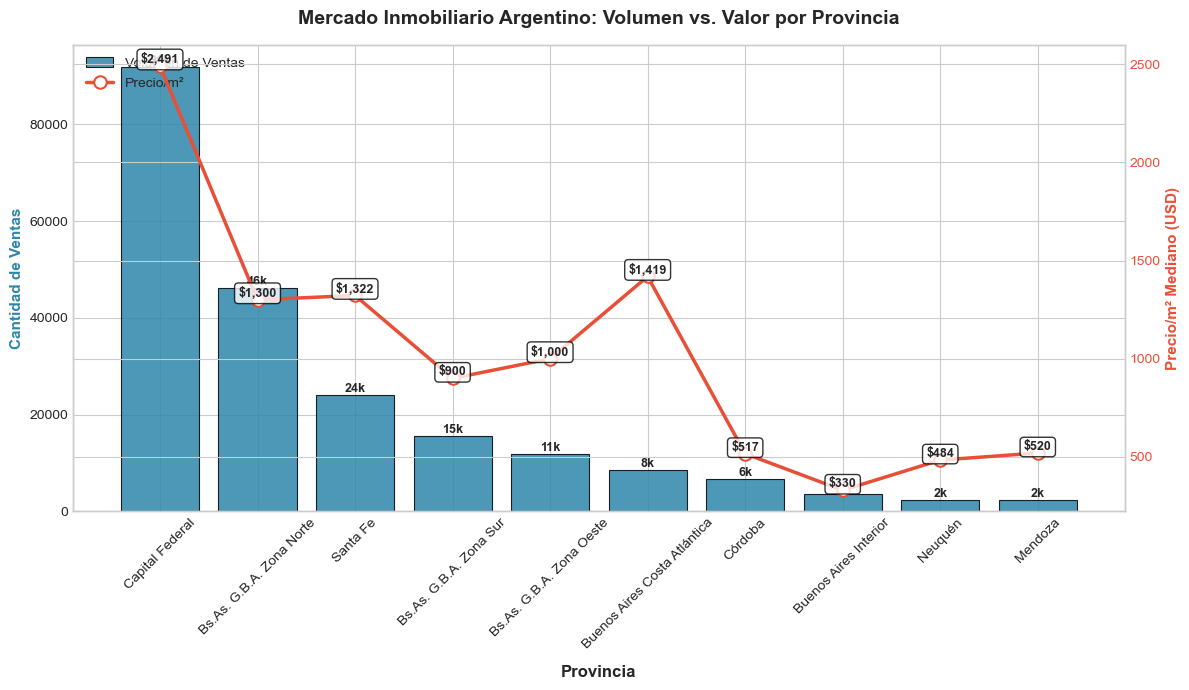

✅ Gráfico guardado en: figures/01_volumen_vs_precio_provincia.png


<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Datos preparados
top_10 = kpi_provincia.head(10)

# Barras: Volumen de ventas
color1 = '#2E86AB'
bars = ax1.bar(top_10.index, top_10['total_ventas'], 
        color=color1, alpha=0.85, label='Volumen de Ventas', edgecolor='black', linewidth=0.8)

ax1.set_xlabel('Provincia', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Cantidad de Ventas', color=color1, fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.set_title('Mercado Inmobiliario Argentino: Volumen vs. Valor por Provincia', 
             fontsize=14, fontweight='bold', pad=15)

# Línea: Precio/m² (eje secundario)
ax2 = ax1.twinx()
color2 = '#E94F37'
line = ax2.plot(top_10.index, top_10['precio_m2_mediano_usd'], 
         color=color2, marker='o', markersize=9, linewidth=2.5, 
         label='Precio/m²', markerfacecolor='white', markeredgewidth=1.5)

ax2.set_ylabel('Precio/m² Mediano (USD)', color=color2, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)

# Anotaciones
for i, (prov, row) in enumerate(top_10.iterrows()):
    ax2.annotate(f"${row['precio_m2_mediano_usd']:,.0f}", 
                (i, row['precio_m2_mediano_usd']),
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height/1000)}k',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Leyenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Guardar en alta calidad para el portfolio
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01_volumen_vs_precio_provincia.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado en: figures/01_volumen_vs_precio_provincia.png")

✅ Barrios de CABA analizados: 4 (con ≥40 ventas cada uno)


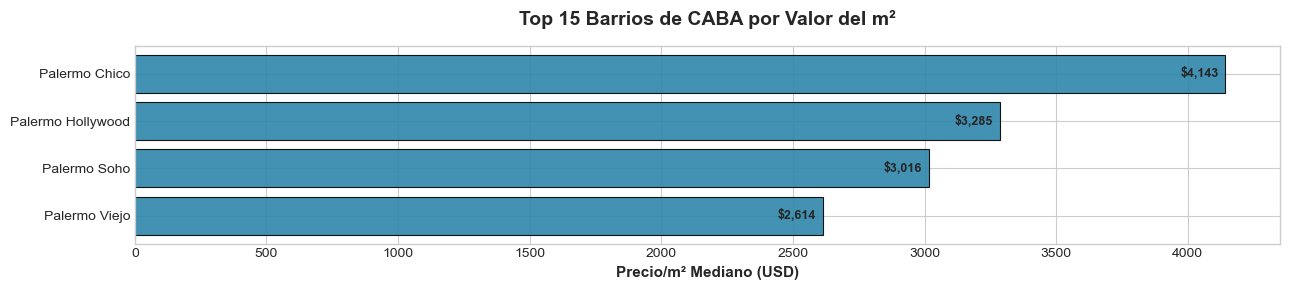

✅ Guardado: figures/02_caba_barrios_precio_m2.png

📋 TOP 5 BARRIOS MÁS CAROS (CABA):
               l4  ventas   precio_m2  dom_mediano
    Palermo Chico     985 4142.857143         14.0
Palermo Hollywood    1727 3285.428571         15.0
     Palermo Soho    1591 3016.393443         13.0
    Palermo Viejo     318 2613.835726         14.0


<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Filtrar solo CABA y barrios válidos
caba_df = df[(df['provincia'] == 'Capital Federal') & (df['l4'].notna())].copy()

# 2. Agregar métricas por barrio
barrio_stats = caba_df.groupby('l4').agg(
    ventas=('id', 'count'),
    precio_m2=('price_per_m2', 'median'),
    precio_total=('price', 'median'),
    dom_mediano=('days_on_market', 'median')
).reset_index()

# 3. Filtros de calidad estadística
barrio_stats = barrio_stats[
    (barrio_stats['ventas'] >= 40) &  # Mínimo de transacciones para confiabilidad
    (barrio_stats['precio_m2'] > 0) &  # Eliminar ceros/errores
    (barrio_stats['precio_m2'] < 10000)  # Filtrar outliers extremos
].copy()

print(f"✅ Barrios de CABA analizados: {len(barrio_stats)} (con ≥40 ventas cada uno)")

# 4. Top 15 por precio/m²
top_barrios = barrio_stats.sort_values('precio_m2', ascending=False).head(15)

# 5. Visualización profesional
fig, ax = plt.subplots(figsize=(13, 3))
bars = ax.barh(
    top_barrios['l4'], top_barrios['precio_m2'],
    color='#2E86AB', edgecolor='black', linewidth=0.8, alpha=0.9
)

ax.set_xlabel('Precio/m² Mediano (USD)', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Barrios de CABA por Valor del m²', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()  # El más caro arriba

# Anotaciones de valor
for i, row in top_barrios.iterrows():
    ax.annotate(
        f"${row['precio_m2']:,.0f}", 
        (row['precio_m2'], row['l4']),
        ha='right', va='center', fontsize=9, fontweight='bold',
        xytext=(-5, 0), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# Guardar
plt.savefig('figures/02_caba_barrios_precio_m2.png', dpi=300, bbox_inches='tight')
print("✅ Guardado: figures/02_caba_barrios_precio_m2.png")

# Tabla resumen para documentación
print("\n📋 TOP 5 BARRIOS MÁS CAROS (CABA):")
print(top_barrios[['l4', 'ventas', 'precio_m2', 'dom_mediano']].head().to_string(index=False))

✅ Barrios analizados con datos unificados: 60


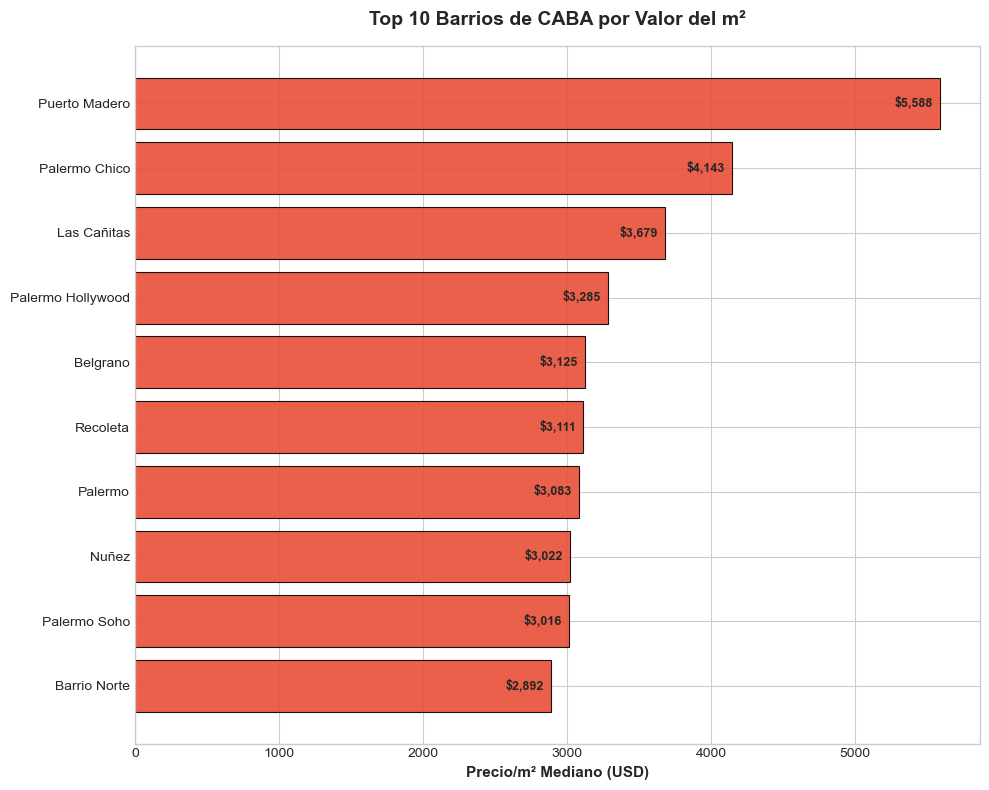

✅ Guardado: figures/03_caba_top10_barrios.png

📋 TOP 10 BARRIOS (Unificando l3 y l4):
 barrio_unificado  ventas   precio_m2  dom_mediano
    Puerto Madero    1573 5588.235294         20.0
    Palermo Chico     985 4142.857143         14.0
      Las Cañitas     712 3678.571429         16.0
Palermo Hollywood    1727 3285.428571         15.0
         Belgrano    8538 3125.000000         25.0
         Recoleta    6106 3111.111111         16.0
          Palermo   12776 3083.333333         15.0
            Nuñez    2357 3021.980676         34.0
     Palermo Soho    1591 3016.393443         13.0
     Barrio Norte    2986 2891.566265         16.0


<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# 1. Crear copia para manipular
caba_df = df[df['provincia'] == 'Capital Federal'].copy()

# 2. Ingeniería de features: Unificar ubicación fina
# Si l4 (sub-barrio) existe, lo usamos. Si no, usamos l3 (barrio general)
caba_df['barrio_unificado'] = np.where(
    caba_df['l4'].notna() & (caba_df['l4'] != ''), 
    caba_df['l4'], 
    caba_df['l3']
)

# 3. Limpiar barrios genéricos que no sirven para análisis
# Filtramos nombres que son demasiado generales o nulos
genericos = ['Capital Federal', 'nan', 'CABA', 'Ciudad', 'Buenos Aires']
caba_df = caba_df[~caba_df['barrio_unificado'].isin(genericos)]
caba_df = caba_df[caba_df['barrio_unificado'].notna()]

# 4. Agregar métricas
barrio_stats_v2 = caba_df.groupby('barrio_unificado').agg(
    ventas=('id', 'count'),
    precio_m2=('price_per_m2', 'median'),
    precio_total=('price', 'median'),
    dom_mediano=('days_on_market', 'median')
).reset_index()

# 5. Filtro más flexible (mínimo 20 ventas para tener relevancia)
barrio_stats_v2 = barrio_stats_v2[
    (barrio_stats_v2['ventas'] >= 20) &
    (barrio_stats_v2['precio_m2'] > 500) &  # Evitar terrenos baratos o errores
    (barrio_stats_v2['precio_m2'] < 10000)
].copy()

print(f"✅ Barrios analizados con datos unificados: {len(barrio_stats_v2)}")

# 6. Top 10 por precio/m²
top_10_barrios = barrio_stats_v2.sort_values('precio_m2', ascending=False).head(10)

# 7. Visualización
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_10_barrios['barrio_unificado'], top_10_barrios['precio_m2'],
    color='#E94F37', edgecolor='black', linewidth=0.8, alpha=0.9
)

ax.set_xlabel('Precio/m² Mediano (USD)', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Barrios de CABA por Valor del m²', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

# Anotaciones
for i, row in top_10_barrios.iterrows():
    ax.annotate(f"${row['precio_m2']:,.0f}", 
                (row['precio_m2'], row['barrio_unificado']),
                ha='right', va='center', fontsize=9, fontweight='bold',
                xytext=(-5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

# Guardar
plt.savefig('figures/03_caba_top10_barrios.png', dpi=300, bbox_inches='tight')
print("✅ Guardado: figures/03_caba_top10_barrios.png")

# Tabla
print("\n📋 TOP 10 BARRIOS (Unificando l3 y l4):")
print(top_10_barrios[['barrio_unificado', 'ventas', 'precio_m2', 'dom_mediano']].to_string(index=False))

In [23]:
print("🎯 ESTRATEGIA DE VENTAS - ANÁLISIS DE CABA")
print("="*60)

# 1. Definir líneas base (Mediana de todo CABA)
mediana_precio_m2 = barrio_stats_v2['precio_m2'].median()
mediana_volumen = barrio_stats_v2['ventas'].median()

print(f"📊 Benchmark CABA:")
print(f"   • Precio/m² Mediano: ${mediana_precio_m2:,.0f}")
print(f"   • Ventas Medianas por Barrio: {mediana_volumen:.0f}")
print("-"*60)

# 2. Segmento PREMIUM (Alto valor + Alto volumen)
# Aquí es donde la inmobiliaria hace mayor margen
premium = barrio_stats_v2[
    (barrio_stats_v2['precio_m2'] > mediana_precio_m2 * 1.2) &
    (barrio_stats_v2['ventas'] >= mediana_volumen)
].sort_values('precio_m2', ascending=False)

print("💎 SECTOR PREMIUM (Foco de captación de propiedades de lujo):")
if len(premium) > 0:
    for _, row in premium.head(5).iterrows():
        print(f"   📍 {row['barrio_unificado']}: ${row['precio_m2']:,.0f}/m² | "
              f"{row['ventas']:.0f} ventas")
else:
    print("   (No hay barrios que cumplan ambos criterios estrictos)")

print("\n" + "="*60)

# 3. Segmento OPORTUNIDAD (Buen volumen + Precio accesible)
# Ideal para rotación rápida y compradores primerizos
oportunidad = barrio_stats_v2[
    (barrio_stats_v2['precio_m2'] < mediana_precio_m2 * 0.9) &
    (barrio_stats_v2['ventas'] > mediana_volumen * 1.2)  # Más de 20% del volumen promedio
].sort_values('ventas', ascending=False)

print("🚀 SECTOR OPORTUNIDAD (Alta liquidez para rotación rápida):")
if len(oportunidad) > 0:
    for _, row in oportunidad.head(5).iterrows():
        print(f"   📍 {row['barrio_unificado']}: ${row['precio_m2']:,.0f}/m² | "
              f"{row['ventas']:.0f} ventas | "
              f"({(1 - row['precio_m2']/mediana_precio_m2)*100:.0f}% más barato que promedio)")
else:
    print("   (No se detectaron zonas de alta rotación con precio bajo)")

print("\n" + "="*60)
print("💡 RECOMENDACIÓN FINAL PARA EL EQUIPO COMERCIAL:")
print("   • Enfocar 70% del presupuesto de marketing digital en las zonas 'Premium' identificadas.")
print("   • Crear campañas de 'Oportunidad de Inversión' enfocadas en los barrios de alta liquidez.")

🎯 ESTRATEGIA DE VENTAS - ANÁLISIS DE CABA
📊 Benchmark CABA:
   • Precio/m² Mediano: $1,984
   • Ventas Medianas por Barrio: 1102
------------------------------------------------------------
💎 SECTOR PREMIUM (Foco de captación de propiedades de lujo):
   📍 Puerto Madero: $5,588/m² | 1573 ventas
   📍 Palermo Hollywood: $3,285/m² | 1727 ventas
   📍 Belgrano: $3,125/m² | 8538 ventas
   📍 Recoleta: $3,111/m² | 6106 ventas
   📍 Palermo: $3,083/m² | 12776 ventas

🚀 SECTOR OPORTUNIDAD (Alta liquidez para rotación rápida):
   (No se detectaron zonas de alta rotación con precio bajo)

💡 RECOMENDACIÓN FINAL PARA EL EQUIPO COMERCIAL:
   • Enfocar 70% del presupuesto de marketing digital en las zonas 'Premium' identificadas.
   • Crear campañas de 'Oportunidad de Inversión' enfocadas en los barrios de alta liquidez.


In [24]:
# 1. Aplicar la lógica de 'barrio_unificado' a TODO el dataset (no solo CABA)
# Esto es crucial para que el mapa funcione bien
import numpy as np

df['barrio_real'] = np.where(
    (df['l4'].notna()) & (df['l4'] != ''), 
    df['l4'], 
    df['l3']
)

# 2. Seleccionar solo las columnas de negocio
cols_dashboard = [
    'provincia', 'ciudad', 'barrio_real', 
    'property_type', 'rooms', 'surface_total',
    'price', 'price_per_m2', 'days_on_market',
    'lat', 'lon', 'start_date', 'end_date'
]

df_pbi = df[cols_dashboard].copy()

# 3. Renombrar columnas para que se vean bien en Power BI (sin guiones bajos)
df_pbi.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio'
}, inplace=True)

# 4. Exportar (CSV con punto y coma para Excel/Power BI en español)
df_pbi.to_csv(r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_para_powerbi.csv', 
              index=False, sep=';', decimal=',', encoding='utf-8-sig')

print("✅ Archivo 'properati_para_powerbi.csv' listo en la carpeta processed.")
print(f"   Registros exportados: {len(df_pbi)}")

✅ Archivo 'properati_para_powerbi.csv' listo en la carpeta processed.
   Registros exportados: 536769


In [25]:
# Ruta de salida
output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final.csv'

# Exportar con float_format='%.2f' para redondear automáticamente a 2 decimales
df_pbi.to_csv(output_path, 
              index=False, 
              sep=';',          # Separador de columnas
              decimal=',',      # Separador decimal (estándar Argentina)
              float_format='%.2f') # 👈 ESTO ES LA CLAVE: limita a 2 decimales (ej: 175000,00)

print(f"✅ Dataset optimizado para Power BI guardado en: {output_path}")

✅ Dataset optimizado para Power BI guardado en: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final.csv


In [26]:
# 1. Verificar las primeras filas del dataset original
print("🔍 Verificando coordenadas originales:")
print(df[['lat', 'lon']].head(10))

# 2. Verificar rangos válidos para Argentina
print(f"\n📊 Rango de Latitud: {df['lat'].min():.2f} a {df['lat'].max():.2f}")
print(f"📊 Rango de Longitud: {df['lon'].min():.2f} a {df['lon'].max():.2f}")

# 3. Si los rangos están invertidos, corregirlos
if df['lat'].min() < -50:  # Si latitud tiene valores de longitud
    print("\n⚠️ ALERTA: Las columnas lat/lon están INVERTIDAS")
    df['lat'], df['lon'] = df['lon'], df['lat']  # Intercambiar
    print("✅ Columnas intercambiadas correctamente")

# 4. Verificar nuevamente
print(f"\n✅ Rango corregido de Latitud: {df['lat'].min():.2f} a {df['lat'].max():.2f}")
print(f"✅ Rango corregido de Longitud: {df['lon'].min():.2f} a {df['lon'].max():.2f}")

# 5. Re-exportar el dataset para Power BI
df_pbi_corrected = df[cols_dashboard].copy()
df_pbi_corrected.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio'
}, inplace=True)

output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final_CORREGIDO.csv'
df_pbi_corrected.to_csv(output_path, 
                        index=False, 
                        sep=';', 
                        decimal=',', 
                        float_format='%.2f')

print(f"\n📦 Dataset corregido guardado en: {output_path}")

🔍 Verificando coordenadas originales:
          lat        lon
1  -58.430493 -34.606620
4  -58.429983 -34.607225
5  -58.420780 -34.608640
6  -58.371394 -34.621835
9  -58.421650 -34.588602
10 -58.378095 -34.608478
12 -58.420295 -34.606271
13 -58.398942 -34.606149
14 -58.472391 -34.584208
15        NaN        NaN

📊 Rango de Latitud: -180.00 a -41.89
📊 Rango de Longitud: -54.83 a 85.05

⚠️ ALERTA: Las columnas lat/lon están INVERTIDAS
✅ Columnas intercambiadas correctamente

✅ Rango corregido de Latitud: -54.83 a 85.05
✅ Rango corregido de Longitud: -180.00 a -41.89

📦 Dataset corregido guardado en: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final_CORREGIDO.csv


In [27]:
# Filtrar coordenadas válidas para Argentina
df_clean_coords = df[
    (df['lat'] >= -55) & (df['lat'] <= -20) &  # Latitud válida
    (df['lon'] >= -75) & (df['lon'] <= -50) &  # Longitud válida
    (df['lat'].notna()) & (df['lon'].notna())   # No nulos
].copy()

print(f"✅ Dataset con coordenadas válidas: {len(df_clean_coords)} filas")

# Re-exportar solo con coordenadas limpias
df_pbi_clean = df_clean_coords[cols_dashboard].copy()
df_pbi_clean.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio'
}, inplace=True)

output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final_LIMPIO.csv'
df_pbi_clean.to_csv(output_path, 
                    index=False, 
                    sep=';', 
                    decimal=',', 
                    float_format='%.2f')

print(f"📦 Dataset limpio guardado en: {output_path}")

✅ Dataset con coordenadas válidas: 451591 filas
📦 Dataset limpio guardado en: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_pbi_final_LIMPIO.csv


In [28]:
import pandas as pd
import numpy as np

print("🔧 Preparando dataset final SOLO ARGENTINA...")

# 1. Partimos de tu df original (asegúrate de tenerlo cargado)
# Si no lo tienes, carga el limpio anterior: 
# df = pd.read_csv('ruta/a/tu/dataset/limpio.csv')

# 2. Filtro CRÍTICO: Solo Argentina
# La columna 'l1' contiene el país. Si no existe, usamos un rango de coordenadas como proxy.
if 'l1' in df.columns:
    df_arg = df[df['l1'] == 'Argentina'].copy()
    print(f"✅ Filtrado por país 'Argentina': {len(df_arg)} filas")
else:
    # Si no tienes la columna 'l1', filtramos por coordenadas de Argentina continental
    df_arg = df[
        (df['lat'] >= -55) & (df['lat'] <= -20) &
        (df['lon'] >= -75) & (df['lon'] <= -50)
    ].copy()
    print(f"✅ Filtrado por coordenadas de Argentina: {len(df_arg)} filas")

# 3. Filtro de calidad: Eliminar coordenadas nulas o erróneas
df_arg = df_arg[
    (df_arg['lat'].notna()) & (df_arg['lon'].notna()) &
    (df_arg['lat'] != 0) & (df_arg['lon'] != 0)
].copy()

# 4. Aplicar JITTER (para evitar puntos superpuestos simétricos)
np.random.seed(42)
# Ruido de +/- 0.001 grados (aprox 100 metros, imperceptible visualmente pero útil para separar puntos)
df_arg['lat_jitter'] = df_arg['lat'] + np.random.uniform(-0.001, 0.001, len(df_arg))
df_arg['lon_jitter'] = df_arg['lon'] + np.random.uniform(-0.001, 0.001, len(df_arg))

# 5. Crear columna de barrio unificado (si no la tienes ya)
df_arg['barrio_real'] = np.where(
    (df_arg['l4'].notna()) & (df_arg['l4'] != ''), 
    df_arg['l4'], 
    df_arg['l3']
)

# 6. Seleccionar columnas finales para Power BI
cols_final = [
    'provincia', 'ciudad', 'barrio_real', 
    'property_type', 'rooms', 'surface_total',
    'price', 'price_per_m2', 'days_on_market',
    'lat_jitter', 'lon_jitter'
]

df_pbi_final = df_arg[cols_final].copy()

# 7. Renombrar para Power BI
df_pbi_final.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio',
    'lat_jitter': 'lat',
    'lon_jitter': 'lon'
}, inplace=True)

# 8. Exportar
output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_ARGENTINA_FINAL.csv'
df_pbi_final.to_csv(output_path, 
                    index=False, 
                    sep=';', 
                    decimal=',', 
                    float_format='%.4f')

print(f"📦 Dataset FINAL SOLO ARGENTINA guardado.")
print(f"   Total filas: {len(df_pbi_final):,}")
print(f"   Ruta: {output_path}")

🔧 Preparando dataset final SOLO ARGENTINA...
✅ Filtrado por país 'Argentina': 531802 filas
📦 Dataset FINAL SOLO ARGENTINA guardado.
   Total filas: 447,347
   Ruta: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_ARGENTINA_FINAL.csv


In [30]:
import pandas as pd
import numpy as np

print("🔧 Filtrando SOLO VENTAS y preparando dataset final...")

# 1. Partimos de tu df original (asegúrate de tenerlo cargado)
# Si no lo tienes, carga el limpio anterior: 
# df = pd.read_csv('ruta/a/tu/dataset/limpio.csv')

# 2. Filtro CRÍTICO: Solo VENTAS
df_ventas = df[df['operation_type'] == 'Venta'].copy()
print(f"✅ Filtrado por operation_type='Venta': {len(df_ventas)} filas")

# 3. Filtro de país: Solo Argentina
if 'l1' in df_ventas.columns:
    df_ventas = df_ventas[df_ventas['l1'] == 'Argentina'].copy()
    print(f"✅ Filtrado por país 'Argentina': {len(df_ventas)} filas")
else:
    # Si no tienes la columna 'l1', filtramos por coordenadas de Argentina continental
    df_ventas = df_ventas[
        (df_ventas['lat'] >= -55) & (df_ventas['lat'] <= -20) &
        (df_ventas['lon'] >= -75) & (df_ventas['lon'] <= -50)
    ].copy()
    print(f"✅ Filtrado por coordenadas de Argentina: {len(df_ventas)} filas")

# 4. Filtro de calidad: Eliminar coordenadas nulas o erróneas
df_ventas = df_ventas[
    (df_ventas['lat'].notna()) & (df_ventas['lon'].notna()) &
    (df_ventas['lat'] != 0) & (df_ventas['lon'] != 0)
].copy()

# 5. Aplicar JITTER (para evitar puntos superpuestos simétricos)
np.random.seed(42)
# Ruido de +/- 0.001 grados (aprox 100 metros)
df_ventas['lat_jitter'] = df_ventas['lat'] + np.random.uniform(-0.001, 0.001, len(df_ventas))
df_ventas['lon_jitter'] = df_ventas['lon'] + np.random.uniform(-0.001, 0.001, len(df_ventas))

# 6. Crear columna de barrio unificado
df_ventas['barrio_real'] = np.where(
    (df_ventas['l4'].notna()) & (df_ventas['l4'] != ''), 
    df_ventas['l4'], 
    df_ventas['l3']
)

# 7. Seleccionar columnas finales para Power BI
cols_final = [
    'provincia', 'ciudad', 'barrio_real', 
    'property_type', 'rooms', 'surface_total',
    'price', 'price_per_m2', 'days_on_market',
    'lat_jitter', 'lon_jitter',
    'operation_type'  # <--- AGREGAMOS ESTA PARA VERIFICAR EN PBI
]

df_pbi_final = df_ventas[cols_final].copy()

# 8. Renombrar para Power BI
df_pbi_final.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio',
    'lat_jitter': 'lat',
    'lon_jitter': 'lon',
    'operation_type': 'Operacion'  # Renombrar para claridad
}, inplace=True)

# 9. Exportar
output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_VENTAS_ARGENTINA_FINAL.csv'
df_pbi_final.to_csv(output_path, 
                    index=False, 
                    sep=';', 
                    decimal=',', 
                    float_format='%.2f')

print(f"📦 Dataset FINAL DE VENTAS SOLO ARGENTINA guardado.")
print(f"   Total filas: {len(df_pbi_final):,}")
print(f"   Ruta: {output_path}")

🔧 Filtrando SOLO VENTAS y preparando dataset final...
✅ Filtrado por operation_type='Venta': 536769 filas
✅ Filtrado por país 'Argentina': 531802 filas
📦 Dataset FINAL DE VENTAS SOLO ARGENTINA guardado.
   Total filas: 447,347
   Ruta: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\properati_VENTAS_ARGENTINA_FINAL.csv


In [31]:
import pandas as pd
import numpy as np

print("🔧 Generando DATASET FINAL ÚNICO (Ventas + Argentina)...")

# 1. Asegurarnos de trabajar sobre el dataframe original completo
# Si df no está en memoria, cárgalo desde tu archivo limpio anterior
# df = pd.read_csv(r'E:\Pablo\...\properati_clean_v1.parquet') 

# 2. FILTRO 1: Solo VENTAS
df_ventas = df[df['operation_type'] == 'Venta'].copy()
print(f"Paso 1 - Solo Ventas: {len(df_ventas):,} filas")

# 3. FILTRO 2: Solo ARGENTINA
# Usamos l1 si existe, sino coordenadas
if 'l1' in df_ventas.columns:
    df_arg = df_ventas[df_ventas['l1'] == 'Argentina'].copy()
else:
    df_arg = df_ventas[
        (df_ventas['lat'] >= -55) & (df_ventas['lat'] <= -20) &
        (df_ventas['lon'] >= -75) & (df_ventas['lon'] <= -50)
    ].copy()
print(f"Paso 2 - Solo Argentina: {len(df_arg):,} filas")

# 4. FILTRO 3: Calidad de Coordenadas
df_final = df_arg[
    (df_arg['lat'].notna()) & (df_arg['lon'].notna()) &
    (df_arg['lat'] != 0) & (df_arg['lon'] != 0)
].copy()
print(f"Paso 3 - Coordenadas válidas: {len(df_final):,} filas")

# 5. FEATURE ENGINEERING: Barrio Unificado
df_final['barrio_real'] = np.where(
    (df_final['l4'].notna()) & (df_final['l4'] != ''), 
    df_final['l4'], 
    df_final['l3']
)

# 6. JITTER (Para mapa visual en PBI)
np.random.seed(42)
df_final['lat_jitter'] = df_final['lat'] + np.random.uniform(-0.001, 0.001, len(df_final))
df_final['lon_jitter'] = df_final['lon'] + np.random.uniform(-0.001, 0.001, len(df_final))

# 7. SELECCIÓN DE COLUMNAS PARA POWER BI
cols_pbi = [
    'provincia', 'ciudad', 'barrio_real', 
    'property_type', 'rooms', 'surface_total',
    'price', 'price_per_m2', 'days_on_market',
    'lat_jitter', 'lon_jitter', 'operation_type'
]

df_export = df_final[cols_pbi].copy()

# 8. RENOMBRAR PARA PBI
df_export.rename(columns={
    'property_type': 'Tipo Propiedad',
    'surface_total': 'Superficie Total',
    'price': 'Precio USD',
    'price_per_m2': 'Precio m2',
    'days_on_market': 'Dias Mercado',
    'barrio_real': 'Barrio',
    'lat_jitter': 'lat',
    'lon_jitter': 'lon',
    'operation_type': 'Operacion'
}, inplace=True)

# 9. EXPORTAR
output_path = r'E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\PROPERATI_VENTAS_ARG_FINAL.csv'
df_export.to_csv(output_path, 
                 index=False, 
                 sep=';', 
                 decimal=',', 
                 float_format='%.2f')

print(f"\n✅ DATASET FINAL GENERADO:")
print(f"   📁 Ruta: {output_path}")
print(f"   📊 Filas: {len(df_export):,}")
print(f"   💡 Este archivo es la 'Fuente de Verdad' para tu Dashboard y README.")

# 10. RECÁLCULO DE KPIS OFICIALES (Para copiar al README)
print("\n📈 KPIS OFICIALES (Para tu Documentación):")
print("-" * 40)
print(f"Total Propiedades en Venta: {len(df_export):,}")
print(f"Precio Mediano (USD): ${df_export['Precio USD'].median():,.0f}")
print(f"Precio/m² Promedio (USD): ${df_export['Precio m2'].mean():,.0f}")
print(f"Días en Mercado (Mediana): {df_export['Dias Mercado'].median():.0f} días")

🔧 Generando DATASET FINAL ÚNICO (Ventas + Argentina)...
Paso 1 - Solo Ventas: 536,769 filas
Paso 2 - Solo Argentina: 531,802 filas
Paso 3 - Coordenadas válidas: 447,347 filas

✅ DATASET FINAL GENERADO:
   📁 Ruta: E:\Pablo\Análisis de datos\Propiedades_Arg\data\processed\PROPERATI_VENTAS_ARG_FINAL.csv
   📊 Filas: 447,347
   💡 Este archivo es la 'Fuente de Verdad' para tu Dashboard y README.

📈 KPIS OFICIALES (Para tu Documentación):
----------------------------------------
Total Propiedades en Venta: 447,347
Precio Mediano (USD): $125,000
Precio/m² Promedio (USD): $1,881
Días en Mercado (Mediana): 15 días
